In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

from scipy.io import arff
import pandas as pd

#os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

2026-04-15 15:57:41.633713: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

data_arff, meta = arff.loadarff('hls4ml_HLF.arff')
df = pd.DataFrame(data_arff)

df['class'] = df['class'].str.decode('utf-8')

X = df.drop(columns=['class'])
y = df['class']

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Features: 16, Samples: 830000


In [3]:
print(X.shape, y.shape)
print(X[:5])
print(y[:5])

(830000, 16) (830000,)
      zlogz  c1_b0_mmdt  c1_b1_mmdt  c1_b2_mmdt  c2_b1_mmdt  c2_b2_mmdt  \
0 -2.935125    0.383155    0.005126    0.000084    0.009070    0.000179   
1 -1.927335    0.270699    0.001585    0.000011    0.003232    0.000029   
2 -3.112147    0.458171    0.097914    0.028588    0.124278    0.038487   
3 -2.666515    0.437068    0.049122    0.007978    0.047477    0.004802   
4 -2.484843    0.428981    0.041786    0.006110    0.023066    0.001123   

   d2_b1_mmdt  d2_b2_mmdt  d2_a1_b1_mmdt  d2_a1_b2_mmdt  m2_b1_mmdt  \
0    1.769445    2.123898       1.769445       0.308185    0.135687   
1    2.038834    2.563099       2.038834       0.211886    0.063729   
2    1.269254    1.346238       1.269254       0.246488    0.115636   
3    0.966505    0.601864       0.966505       0.160756    0.082196   
4    0.552002    0.183821       0.552002       0.084338    0.048006   

   m2_b2_mmdt  n2_b1_mmdt  n2_b2_mmdt   mass_mmdt  multiplicity  
0    0.083278    0.412136    0.29

In [4]:
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y, 5)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y[:5])

[[1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]]


In [5]:
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)

In [6]:
np.save('X_train_val.npy', X_train_val)
np.save('X_test.npy', X_test)
np.save('y_train_val.npy', y_train_val)
np.save('y_test.npy', y_test)
np.save('classes.npy', le.classes_)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_deepjet_model(input_dim=16, num_classes=5):
    """
    Keras implementation of a DeepJet-style Residual MLP.
    Optimized for high-level jet observables.
    """
    # 1. Input Layer
    inputs = layers.Input(shape=(input_dim,), name="Jet_Observables")
    
    # 2. Pre-processing / Scaling (Optional but recommended)
    # Standardizing inputs often helps with high-energy physics scales
    x = layers.BatchNormalization()(inputs)
    
    # 3. Dense Blocks with Residual Connections
    def residual_block(x, nodes, dropout_rate=0.1):
        shortcut = x
        x = layers.Dense(nodes, activation='selu', kernel_initializer='lecun_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(nodes, activation='selu', kernel_initializer='lecun_normal')(x)
        x = layers.BatchNormalization()(x)
        
        # Add residual connection if shapes match
        if shortcut.shape[-1] == nodes:
            x = layers.Add()([x, shortcut])
        return x

    # Feature extraction layers
    x = layers.Dense(256, activation='selu', kernel_initializer='lecun_normal')(x)
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    
    # Bottleneck layer
    x = layers.Dense(128, activation='selu', kernel_initializer='lecun_normal')(x)
    x = layers.Dropout(0.1)(x)
    
    # 4. Classification Output
    outputs = layers.Dense(num_classes, activation='softmax', name="Classification")(x)
    
    # Create model
    model = models.Model(inputs=inputs, outputs=outputs, name="DeepJet_Basic")
    
    return model

# Initialize model
model = build_deepjet_model(input_dim=16, num_classes=5)

# Compile with standard HEP settings
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()


Model: "DeepJet_Basic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Jet_Observables     │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ Jet_Observables[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │      4,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │     65,792 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │     65,792 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │     65,792 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │     32,896 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classification      │ (None, 5)         │        645 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 305,221 (1.16 MB)

 Trainable params: 303,141 (1.16 MB)

 Non-trainable params: 2,080 (8.12 KB)

In [25]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Create the output directory manually
os.makedirs('model_baseline', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=1000, verbose=1),
    ModelCheckpoint(filepath='model_baseline/best_model.weights.h5', monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0000001, verbose=1),
]

adam = Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])
model.fit(
    X_train_val, 
    y_train_val, 
    epochs=100, 
    batch_size=1024, 
    validation_split=0.25, 
    shuffle=True, 
    callbacks=callbacks
)
model.save('model_baseline/KERAS_check_best_model.h5')

Epoch 1/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5902 - loss: 1.1538
Epoch 1: val_loss improved from None to 0.78045, saving model to model_baseline/best_model.weights.h5

Epoch 1: finished saving model to model_baseline/best_model.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.6518 - loss: 0.9812 - val_accuracy: 0.7374 - val_loss: 0.7804 - learning_rate: 1.0000e-04
Epoch 2/100
480/487 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7123 - loss: 0.8302
Epoch 2: val_loss improved from 0.78045 to 0.73055, saving model to model_baseline/best_model.weights.h5

Epoch 2: finished saving model to model_baseline/best_model.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7197 - loss: 0.8082 - val_accuracy: 0.7472 - val_loss: 0.7306 - learning_rate: 1.0000e-04
Epoch 3/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7303 - loss: 0.7731
Epoch 3: val_loss improved from 0.73055 to 0.70724, saving model to model_baseline/best_model.w

In [26]:
w = model.layers[0].weights[0].numpy()
h, b = np.histogram(w, bins=100)
plt.figure(figsize=(7, 7))
plt.bar(b[:-1], h, width=b[1] - b[0])
plt.semilogy()
print('% of zeros = {}'.format(np.sum(w == 0) / np.size(w)))

IndexError: list index out of range

In [27]:
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

# 3. Evaluate

score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

2026-04-15 16:17:21.416765: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-15 16:17:22.283937: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_226', 16 bytes spill stores, 16 bytes spill loads



Test loss: 0.6374032497406006
Test accuracy: 0.7698915600776672


In [15]:
score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

2026-04-15 16:04:50.593382: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 10624000 exceeds 10% of free system memory.


Test loss: 0.8585432767868042
Test accuracy: 0.7476626634597778


In [28]:
y_hgq = model.predict(X_test)
hgq_size = y_hgq.size

5188/5188 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Accuracy: 0.7698915662650603


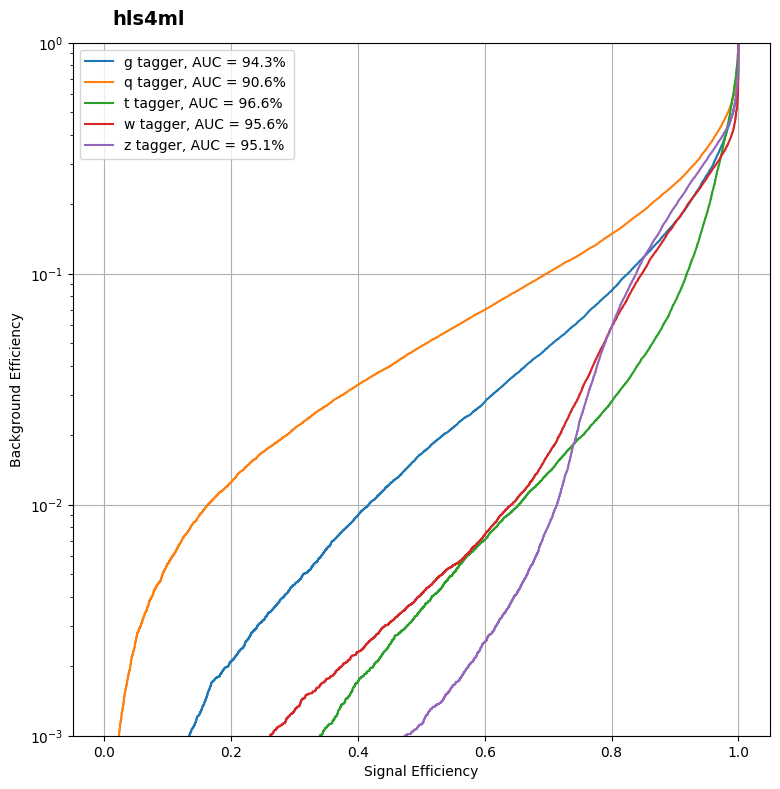

In [29]:
import plotting
from sklearn.metrics import accuracy_score

y_hgq = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hgq, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_hgq, le.classes_)

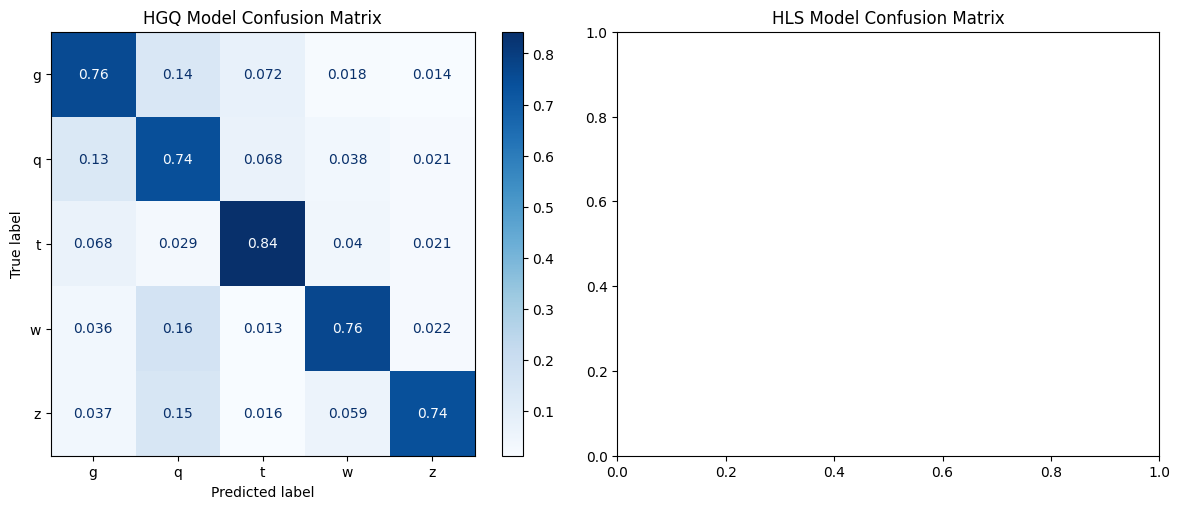

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_hgq_pred = np.argmax(y_hgq, axis=1)
y_hgq_true = np.argmax(y_test, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
cm_hgq = confusion_matrix(y_hgq_true, y_hgq_pred, normalize='true')

# Plot it
disp_hgq = ConfusionMatrixDisplay(confusion_matrix=cm_hgq, display_labels=le.classes_)
disp_hgq.plot(ax=ax[0],cmap=plt.cm.Blues)
ax[0].set_title('HGQ Model Confusion Matrix')

ax[1].set_title('HLS Model Confusion Matrix')

plt.tight_layout()
plt.show()